<h1 style="text-align:center; color:red;">Mini Project: Data Visualization with Pandas, Seaborn, and Matplotlib</h1>

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Style
sns.set(style="whitegrid")

# Display plots
%matplotlib inline

In [6]:
# Load dataset  
penguins = pd.read_csv("Palmer Penguins Dataset.csv")

# Display first rows
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [8]:
# Check missing values
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [10]:
# Remove rows with missing values
penguins_clean = penguins.dropna()

# Verify dataset shape
penguins_clean.shape

(333, 8)

In [12]:
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [14]:
penguins_clean.nunique()

species                3
island                 3
bill_length_mm       163
bill_depth_mm         79
flipper_length_mm     54
body_mass_g           93
sex                    2
year                   3
dtype: int64

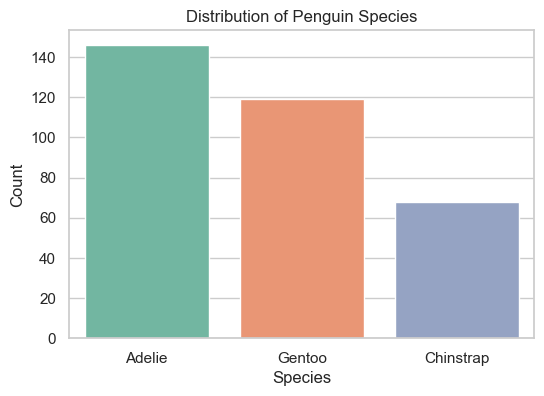

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=penguins_clean, x="species", hue="species", palette="Set2", legend=False
)

plt.title("Distribution of Penguin Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Flipper Length vs Body Mass (Scatter Plot)

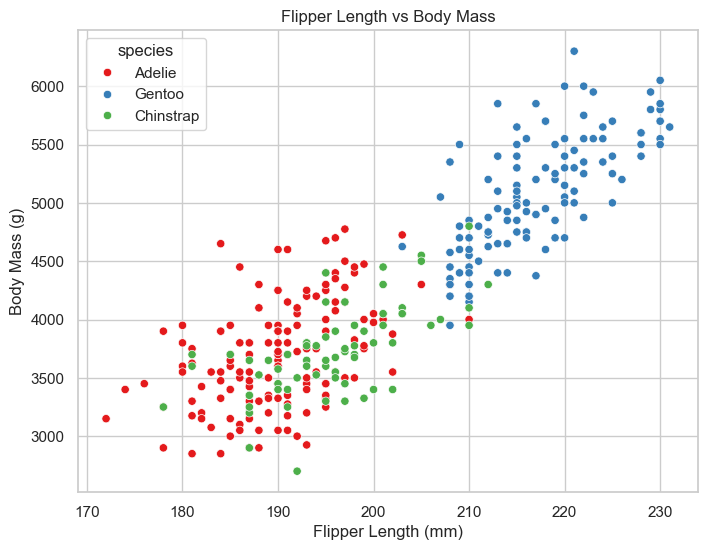

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Set1"
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")

plt.show()

### Island Distribution (Pie Chart)

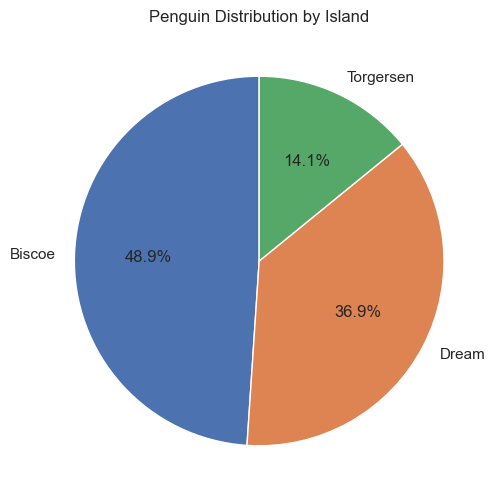

In [24]:
island_counts = penguins_clean["island"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    island_counts,
    labels=island_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Penguin Distribution by Island")

plt.show()

### Sex Distribution within Species (Grouped Bar Chart)

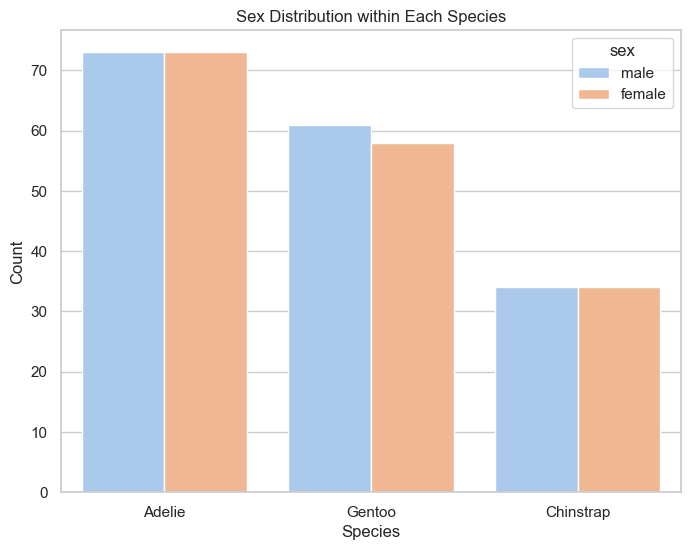

In [27]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=penguins_clean,
    x="species",
    hue="sex",
    palette="pastel"
)

plt.title("Sex Distribution within Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Heatmap of Correlations

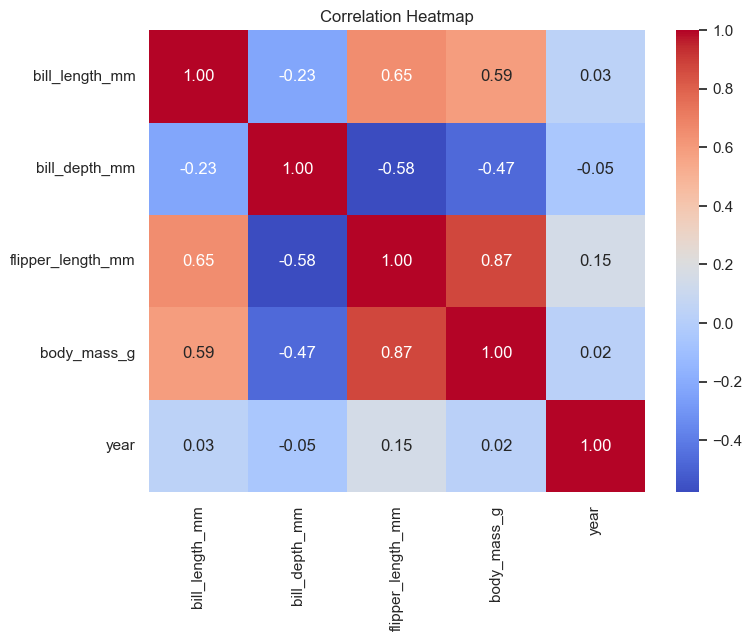

In [32]:
plt.figure(figsize=(8,6))

corr = penguins_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Boxplots for Measurements by Species

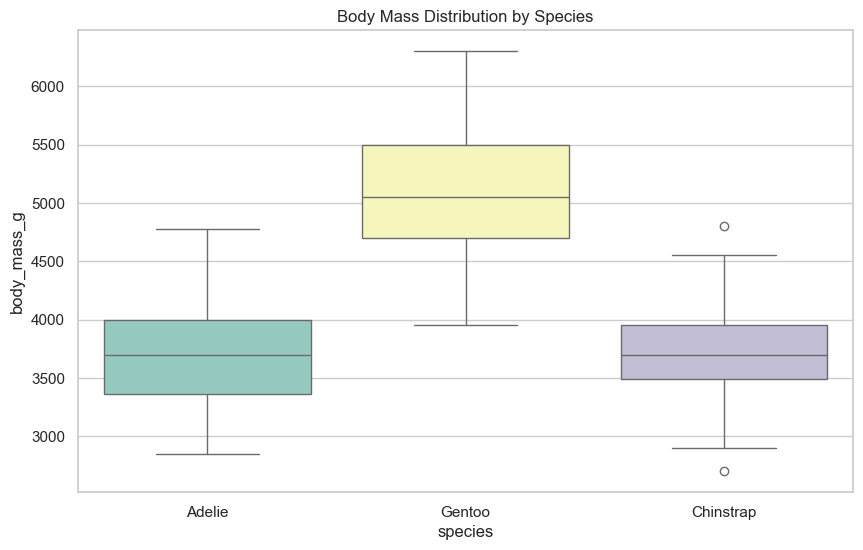

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=penguins_clean,
    x="species",
    y="body_mass_g",
    hue="species", palette="Set3", legend=False
)

plt.title("Body Mass Distribution by Species")

plt.show()

### Histograms of Measurements

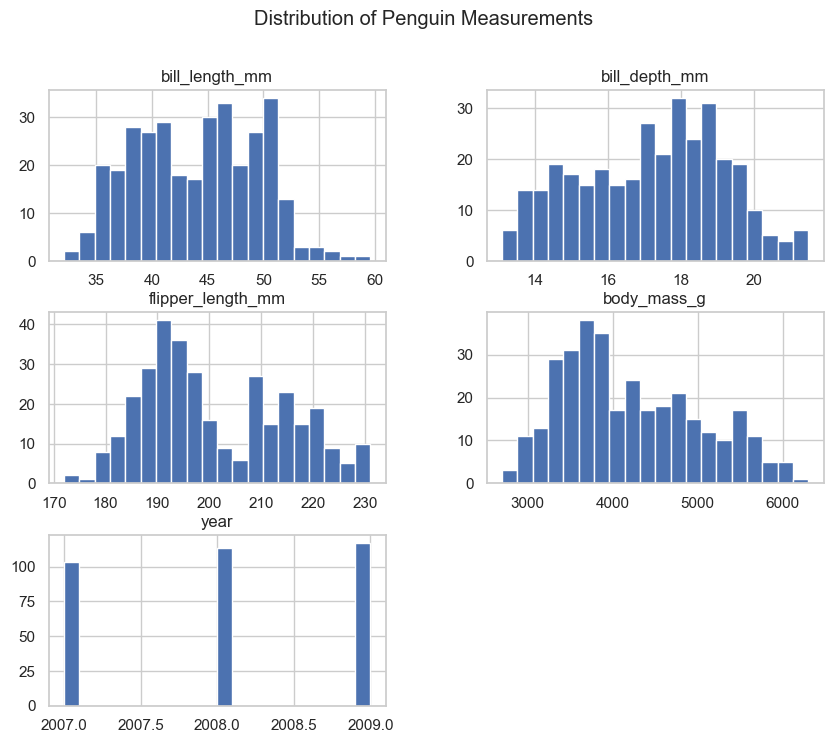

In [40]:
penguins_clean.hist(
    figsize=(10,8),
    bins=20
)

plt.suptitle("Distribution of Penguin Measurements")

plt.show()

### Multiple Subplots

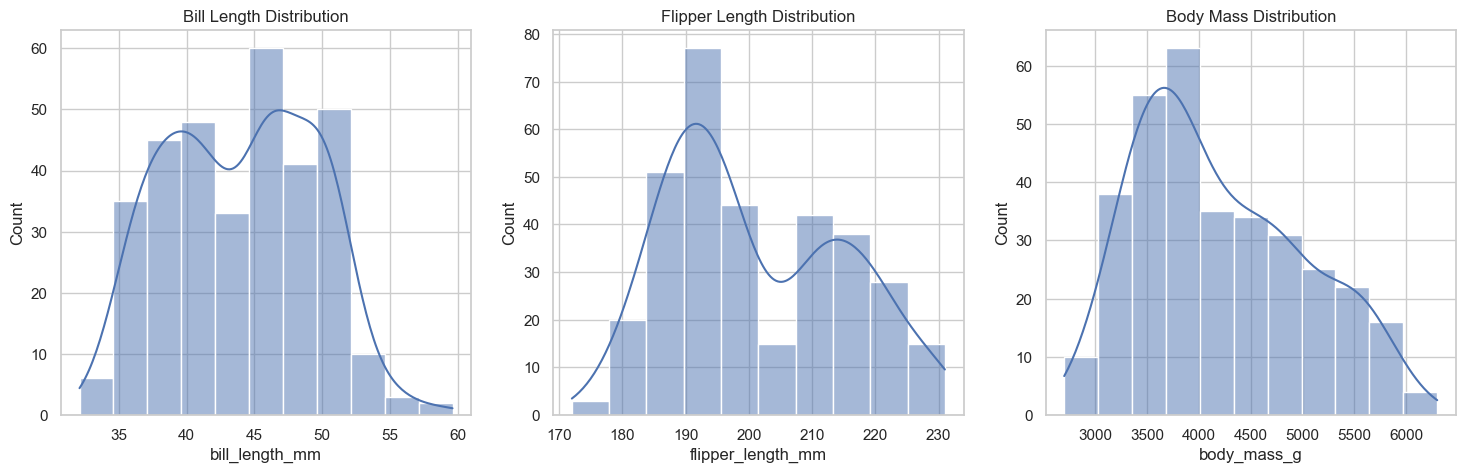

In [43]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(penguins_clean["bill_length_mm"], ax=axes[0], kde=True)
axes[0].set_title("Bill Length Distribution")

sns.histplot(penguins_clean["flipper_length_mm"], ax=axes[1], kde=True)
axes[1].set_title("Flipper Length Distribution")

sns.histplot(penguins_clean["body_mass_g"], ax=axes[2], kde=True)
axes[2].set_title("Body Mass Distribution")

plt.show()

### Pairplot (Advanced Seaborn Visualization)

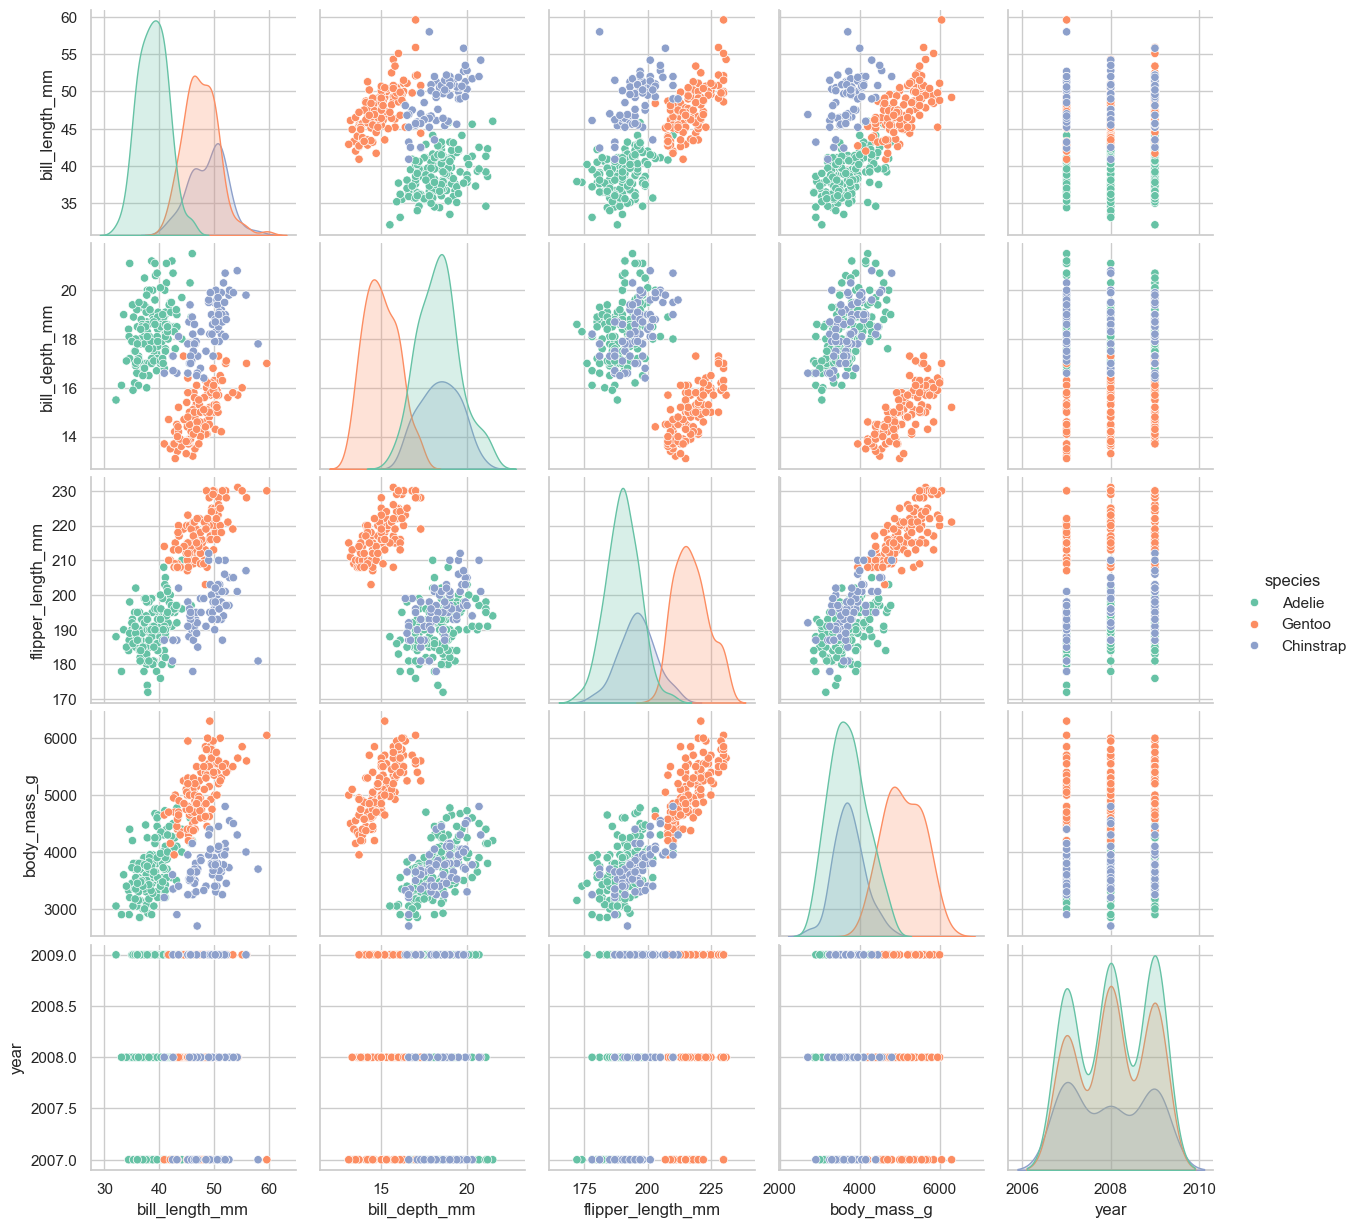

In [46]:
sns.pairplot(
    penguins_clean,
    hue="species",
    palette="Set2"
)

plt.show()

## Conclusion

This analysis of the Palmer Penguins dataset revealed several key insights:

- Adelie penguins are the most common species in the dataset.
- Gentoo penguins have larger body mass and flipper lengths.
- There is a strong positive relationship between flipper length and body mass.
- Penguins are distributed across three islands, with Biscoe having the highest count.
- Pairwise visualizations highlight distinct morphological differences between species.